# Notebook: Bilinear interpolation and image rotations

![](pictures/logo300px.png)

## Linear interpolation

This notebook has been written with some Linear Algebra in mind. We start with a drawing (forget this code) which shows how we can program a linear interpolation. Later we describe how we can implement a bilinear interpolation.

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Linear-interpolation" data-toc-modified-id="Linear-interpolation-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Linear interpolation</a></span><ul class="toc-item"><li><span><a href="#Vector-representation-of-a-line-between-two-positions" data-toc-modified-id="Vector-representation-of-a-line-between-two-positions-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Vector representation of a line between two positions</a></span></li><li><span><a href="#Linear-interpolation-on-a-regular-grid" data-toc-modified-id="Linear-interpolation-on-a-regular-grid-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Linear interpolation on a regular grid</a></span></li><li><span><a href="#What-is-the-interpolated-intensity-at-$Xip=1.3$?" data-toc-modified-id="What-is-the-interpolated-intensity-at-$Xip=1.3$?-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>What is the interpolated intensity at $Xip=1.3$?</a></span></li><li><span><a href="#Safeguarding-against-non-existing-indices" data-toc-modified-id="Safeguarding-against-non-existing-indices-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Safeguarding against non-existing indices</a></span></li></ul></li><li><span><a href="#Bilinear-interpolation" data-toc-modified-id="Bilinear-interpolation-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Bilinear interpolation</a></span><ul class="toc-item"><li><span><a href="#Confusing-coordinate-systems" data-toc-modified-id="Confusing-coordinate-systems-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Confusing coordinate systems</a></span></li><li><span><a href="#Interpolation-in-two-directions" data-toc-modified-id="Interpolation-in-two-directions-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Interpolation in two directions</a></span></li><li><span><a href="#Summary-in-a-plot" data-toc-modified-id="Summary-in-a-plot-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Summary in a plot</a></span></li><li><span><a href="#The-implementation-of-the-algorithm-in-a-function" data-toc-modified-id="The-implementation-of-the-algorithm-in-a-function-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>The implementation of the algorithm in a function</a></span></li><li><span><a href="#Verify-the-result-with-a-SciPy-routine" data-toc-modified-id="Verify-the-result-with-a-SciPy-routine-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Verify the result with a SciPy routine</a></span></li><li><span><a href="#An-implementation-using-matrix-multiplications" data-toc-modified-id="An-implementation-using-matrix-multiplications-2.6"><span class="toc-item-num">2.6&nbsp;&nbsp;</span>An implementation using matrix multiplications</a></span></li><li><span><a href="#Using-function-multi_dot" data-toc-modified-id="Using-function-multi_dot-2.7"><span class="toc-item-num">2.7&nbsp;&nbsp;</span>Using function <code>multi_dot</code></a></span></li><li><span><a href="#A-function-using-multi_dot-for-bilinear-interpolation" data-toc-modified-id="A-function-using-multi_dot-for-bilinear-interpolation-2.8"><span class="toc-item-num">2.8&nbsp;&nbsp;</span>A function using multi_dot for bilinear interpolation</a></span></li></ul></li><li><span><a href="#Image-interpolation" data-toc-modified-id="Image-interpolation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Image interpolation</a></span><ul class="toc-item"><li><span><a href="#Template-program-for-regridding" data-toc-modified-id="Template-program-for-regridding-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Template program for regridding</a></span></li><li><span><a href="#Rotating-an-image-using-bilinear-interpolation" data-toc-modified-id="Rotating-an-image-using-bilinear-interpolation-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Rotating an image using bilinear interpolation</a></span></li><li><span><a href="#Speeding-up-the-rotation" data-toc-modified-id="Speeding-up-the-rotation-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Speeding up the rotation</a></span></li><li><span><a href="#Speeding-up-with-numpy.ndindex-by-avoiding-an-inner-loop" data-toc-modified-id="Speeding-up-with-numpy.ndindex-by-avoiding-an-inner-loop-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Speeding up with <code>numpy.ndindex</code> by avoiding an inner loop</a></span></li><li><span><a href="#Avoiding-cutoffs" data-toc-modified-id="Avoiding-cutoffs-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Avoiding cutoffs</a></span><ul class="toc-item"><li><span><a href="#The-bilinear-interpolation-function-bilinearIP" data-toc-modified-id="The-bilinear-interpolation-function-bilinearIP-3.5.1"><span class="toc-item-num">3.5.1&nbsp;&nbsp;</span>The bilinear interpolation function <code>bilinearIP</code></a></span></li><li><span><a href="#Read-the-input-data" data-toc-modified-id="Read-the-input-data-3.5.2"><span class="toc-item-num">3.5.2&nbsp;&nbsp;</span>Read the input data</a></span></li><li><span><a href="#Calculating-a-new-box-by-rotating-the-limits-of-the-input-data" data-toc-modified-id="Calculating-a-new-box-by-rotating-the-limits-of-the-input-data-3.5.3"><span class="toc-item-num">3.5.3&nbsp;&nbsp;</span>Calculating a new box by rotating the limits of the input data</a></span></li><li><span><a href="#Use-the-new-limits-to-sample-the-output-image" data-toc-modified-id="Use-the-new-limits-to-sample-the-output-image-3.5.4"><span class="toc-item-num">3.5.4&nbsp;&nbsp;</span>Use the new limits to sample the output image</a></span></li></ul></li></ul></li><li><span><a href="#Rotation-routines-from-Python-modules" data-toc-modified-id="Rotation-routines-from-Python-modules-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Rotation routines from Python modules</a></span><ul class="toc-item"><li><span><a href="#Rotate-with-the-ndimage-module-from-SciPy" data-toc-modified-id="Rotate-with-the-ndimage-module-from-SciPy-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Rotate with the <code>ndimage</code> module from SciPy</a></span></li><li><span><a href="#Rotation-with-module-Pillow" data-toc-modified-id="Rotation-with-module-Pillow-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Rotation with module Pillow</a></span></li><li><span><a href="#Rotate-an-image-with-OpenCV" data-toc-modified-id="Rotate-an-image-with-OpenCV-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Rotate an image with OpenCV</a></span></li></ul></li></ul></div>

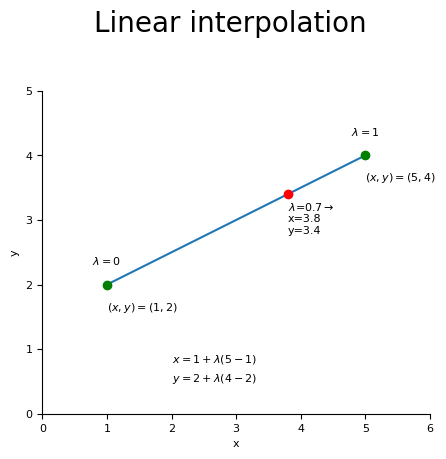

In [1]:
from matplotlib.pyplot import figure, show, xkcd, rc
from matplotlib.patches import Arc
import numpy as np

rc('font', size=8)

# Based on "Stove Ownership" from XKCD by Randall Monroe
# http://xkcd.com/418/
if 1:   #with xkcd():
    # This figure will be in XKCD-style
    fig = figure(figsize=(5,5))
    frame = fig.add_subplot(1,1,1, aspect=1)
    frame.spines['left'].set_position('zero')
    frame.spines['right'].set_color('none')
    frame.spines['bottom'].set_position('zero')
    frame.spines['top'].set_color('none')
    frame.xaxis.set_ticks_position('bottom')
    frame.yaxis.set_ticks_position('left')
    fig.suptitle("Linear interpolation", fontsize=20)
    xy1 = (1,2); xy2 = (5,4)
    frame.plot((xy1[0],xy2[0]), (xy1[1], xy2[1]))
    frame.plot([xy1[0]], [xy1[1]], marker='o', color='g')
    frame.plot([xy2[0]], [xy2[1]], marker='o', color='g')
    frame.set_xlim(0, xy2[0]+1)
    frame.set_ylim(0, xy2[1]+1)
    frame.text(xy1[0]+1, xy1[1]-1.2, r"$x = 1 + \lambda (5 - 1)$")
    frame.text(xy1[0]+1, xy1[1]-1.5, r"$y = 2 + \lambda (4 - 2)$")
    frame.text(xy1[0], xy1[1]+0.3, r"$\lambda = 0$", ha='center')
    frame.text(xy2[0], xy2[1]+0.3, r"$\lambda = 1$", ha='center')
    frame.text(xy1[0], xy1[1]-0.4, f"$(x,y)=({xy1[0]},{xy1[1]})$")
    frame.text(xy2[0], xy2[1]-0.4, f"$(x,y)=({xy2[0]},{xy2[1]})$")
    Lambda = 0.7
    x = xy1[0] + Lambda*(xy2[0]-xy1[0])
    y = xy1[1] + Lambda*(xy2[1]-xy1[1])
    frame.plot([x], [y], marker='o', color='r')
    s = f"$\lambda$={Lambda}$ \\rightarrow $\nx={x}\ny={y}"
    frame.text(x, y-0.1, s, va='top')
    frame.set_xlabel("x")
    frame.set_ylabel("y")
show()    

### Vector representation of a line between two positions

Assume you have two point with coordinates $A=(x_0,y_0)$ and $B=(x_1, y_1)$. How can we calculate the value of $y$ at a position $x$? There are many solutions for this but we prefer to do this with some Linear Algebra.

Remember that if we take these positions as vectors $\vec{A}$ and $\vec{B}$ then 

$$\vec{A} = \begin{bmatrix}x_0\\y_0\end{bmatrix} \text{,   } \vec{B} = \begin{bmatrix}x_1\\y_1\end{bmatrix}$$

A vector representation of the line that connects $(x_0,y_0)$ and $(x_1, y_1)$ is then:

$$\begin{bmatrix}x\\y\end{bmatrix} = \vec{A} + \lambda(\vec{B}-\vec{A}) = 
\begin{bmatrix}x_0\\y_0\end{bmatrix} + \lambda\begin{bmatrix}x_1-x_0\\y_1-y_0\end{bmatrix}
$$

Note that at $\lambda=0$, $x=x_0$ and $y=y_0$ which is the start point of the line, while at $\lambda=1$ we have $x=x_1$ and $y=y_1$ which is the end point of the line.

Now assume that the $y$ values represent intensities, let's say $y_0$ = $I_0$ and $y_1$ = $I_1$.  
Then at a certain value of $\lambda$ you find that $x = x_0 + \lambda (x_1-x_0)$ while the interpolated intensity 
$I=I_0+ \lambda (I_1-I_0)$.  
Usually you have a value of $x$ at which you want to find the interpolated intensity, so you have to calculate $\lambda$ first.

In [2]:
# What is Lambda at x = 3.8?
Xip = 3.8
xstart = xy1[0]; xend = xy2[0]
Lambda = (Xip-xstart)/(xend-xstart)
print(f"At the interpolation position Xip={Xip} the value for Lambda={Lambda}")

At the interpolation position Xip=3.8 the value for Lambda=0.7


### Linear interpolation on a regular grid
In astronomy we often apply linear interpolation for $x$ values on a regular grid.  
Then we take the $x$ values as integers which correspond to index numbers in an array with intensities.  
For example:

``I = np.array([1000, 1100, 1400])``

Then the $x$ values that correspond to $I$ are 0, 1 and 2.  
Usually we generate these $x$ values on a grid with the following code:

In [3]:
I = np.array([1000, 1100, 1400])
xgrid = np.arange(I.size)
print(xgrid)

[0 1 2]


### What is the interpolated intensity at $Xip=1.3$?

By using a regular grid we can for a given value of $x$ always find the left and right intensity on the grid.
If we set the position of the left intensity to 0 and that of the right intensity to 1, then this simplifies our formulas. 

We find those left and right intensities for our given $Xip=1.3$ by observing that $Xip$ is between 1 and 2. So we take:

$$I_0=I[int(Xip)]  \quad \quad I_1=I[int(Xip)+1]$$. 

We dis set $x_0=0$ and $x_1=1$ 
for which then automatically follows that $\lambda=0.3$.
One can find $\lambda$ for a given $x$ with:

``lambda = Xip - int(Xip)``

With this information we rewrite our interpolation formula. With $I_{ip}$ as the required interpolated intensity, at position $X_{ip}$ it becomes:

$$\begin{bmatrix}X_{ip}\\I_{ip}\end{bmatrix}  = 
\begin{bmatrix}0\\I_0\end{bmatrix} + \lambda\begin{bmatrix}1\\I_1-I_0\end{bmatrix}
$$

which confirms that for $\lambda=0$ we identified the left position with intensity $I_0$ and for
$\lambda=1$ we have the position at the right with intensity $I_1$.

Let's make a Python function for this:

In [4]:
import numpy as np

def linearIP(I, X):
    '''A is a one dimensional array and x is the position at 
       which we want to interpolate. x must be bigger or equal to 0 and 
       smaller than the highest index of I'''
    indx = int(X)
    Lambda = X - int(X)
    I0 = I[indx]
    I1 = I[indx+1]
    Iintp = I0 + Lambda*(I1-I0)
    return(Iintp)


I = np.array([1000, 1100, 1400])
x = 1.3
Iip = linearIP(I, x)
print(f"The interpolated intensity at x={x} is {Iip}")

The interpolated intensity at x=1.3 is 1190.0


In the next cell we use IPython widgets for an interactive program to check our algorithm.
It uses a slider. The value of the slider is our position $x$. The program shows the interpolated intensity.

In [5]:
from ipywidgets import interact

@interact(Xip=(0.0, 2-0.0001, 0.05))
def p(Xip=1):
    Iip = linearIP(I, Xip)
    print("Xip=",Xip, "\nIip=",Iip)
    pass

interactive(children=(FloatSlider(value=1.0, description='Xip', max=1.9999, step=0.05), Output()), _dom_classe…

Note that the slider cannot reach value 2. That is because at $x=2$ the index value for the neighbour is 3 and there is no element with index 3. So we should decide what to do then to protect our program from crashing.

If the position of $x$ corresponds to an index at the end of the array, we should return the value of the last intensity. Also, the value of $x$ should not be negative. In that case we return the first intensity in the array. This can be implemented as follows:

### Safeguarding against non-existing indices

In [6]:
def linearIP(I, X):
    '''A is a one dimensional array and x is the position at 
       which we want to interpolate. x must be bigger or equal to 0 and 
       smaller than the highest index of I'''
    indx = int(X)
    if indx < 0:
        return I[0]
    if indx+1 >= I.size:
        return I[-1]
    
    Lambda = X - int(X)
    I0 = I[indx]
    if indx+1 < I.size:
        I1 = I[indx+1]
    else:
        I1 = I[indx]
    Iintp = I0 + Lambda*(I1-I0)
    return(Iintp)

@interact(x=(0.0, 2, 0.05))
def p(x=1):
    Iip = linearIP(I, x)
    print("x=",x, "\nI=",Iip)
    pass

interactive(children=(FloatSlider(value=1.0, description='x', max=2.0, step=0.05), Output()), _dom_classes=('w…

## Bilinear interpolation

### Confusing coordinate systems

Historically, TV's draw their lines from left to right and from top to bottom.  
Cartesian coordinate systems have $y$ increasing from bottom to top. 
Most image formats (PNG, JPG etc.) plot their data from top to bottom.
This is comparable how a two-dimensional NumPy array is printed.  
But in astronomy we use the FITS format a lot and there the data should be displayed with $y$ increasing towards the top. That is the reason we need to set ``origin='lower'`` in Matplotlib's ``imshow()`` function.

We can get a consistent view on the matter when we take a coordinate system with the origin of $y$ at the top to reflect the indices of a matrix $A_{ij}$ where we agreed that $i$ represents the row ($i$ increases from top the bottom),
and $j$ represents the column ($j$ increases from left to right).

Here we see a lucky resemblance between indices of a two dimensional NumPy array and a matrix from Linear Algebra.
In the latter we start with indices $i=1$ and $j=1$ while the first element in a two dimensional NumPy array $M[0,0]$.

So for images, one should have a matrix from Linear Algebra in mind. If one needs to work in a Cartesian coordinate system, you have to do some conversions from Cartesian coordinates to NumPy array indices.

Note that for images we assume a rectangular grid system for which the image values are defined.

### Interpolation in two directions
A simple approach to bilinear interpolation is that one can interpolate first in the direction of $j$ (columns) to get two interpolated intensities. These are linearly interpolated in the direction of $i$ (rows).

Assume we have 4 pixels from a two dimensional structure (e.a. a 2-dim NumPy array that represents an image).
If we follow the standard indexing from Linear Algebra then we can represent the intensities as:

$$M = \begin{bmatrix}I_{i,\ j} & I_{i,\ j+1}\\I_{i+1,\ j} & I_{i+1,\ j+1}\end{bmatrix}$$

For simplicity, let's write:

$$M = \begin{bmatrix}I_{0} & I_{1}\\I_{2} & I_{3}\end{bmatrix}$$

At certain position $j_f$ between two columns given by ${\lambda}$ (remember: ${\lambda}=0$ at $I0$ and ${\lambda}=1$ at $I1$) we have the interpolated intensity for $I_0$ and $I_1$ which is:

$$I_{y0} = I_0 + \lambda(I_1-I_0)$$

For the same value of $\lambda$ we also find an interpolated value for $I_2$ and $I_3$:

$$I_{y1} = I_2 + \lambda(I_3-I_2)$$

At certain position $i_f$ between two rows given by $\mu$ (remember: $\mu=0$ for the top row and $\mu=1$ for the bottom row) we can now interpolate in the $y$ direction to obtain:

$$I_{ip} = I_{y0} + \mu(I_{y1}-I_{y0})$$

If we insert $I_{y0}$ and $I_{y0}$ in this last equation we get:

$$I_{ip}=(1-\lambda)I_0+\lambda I_1+\mu\Big[1-\lambda)I_2+\lambda I_3-\big( (1-\lambda)I_0+\lambda I_1\big)  \Big]$$

which simplifies into:

$$\boxed{I_{ip}= (1-\lambda)(1-\mu)I_0 + \lambda(1-\mu)I_1 + \mu (1-\lambda)I_2+\lambda \mu I_3}$$

A position at which we want to interpolate can be given by (usually two floating point numbers) $(i_f, j_f)$.  
Then it is obvious that for the indices of the upper left intensity $I_0$ we find:

$$i=int(\,i_f\,)$$
$$j=int(\,j_f\,)$$

Python function ``int()`` returns the integer part of a floating point number.

For the offsets $\lambda$ and $\mu$ we find 

$$\lambda = j_f - j$$
$$\mu = i_f - i$$

### Summary in a plot
We created a plot to help you to understand what we wrote in the previous cell. Forget the code, just focus on the plot.

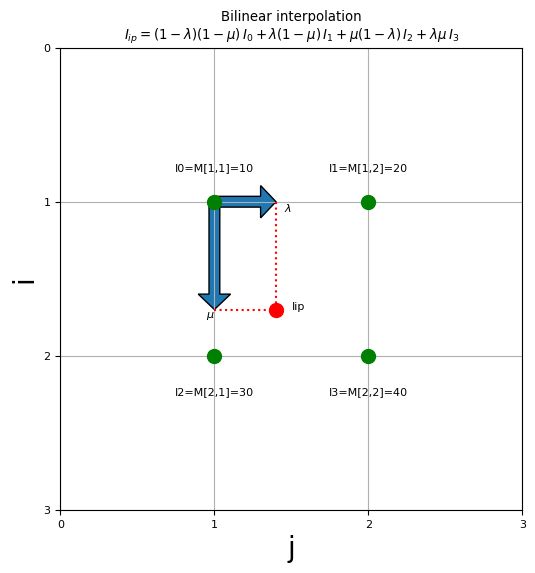

In [7]:
from matplotlib.pyplot import figure, show, xkcd, rc
import numpy as np

rc('font', size=8)
if 1: #with xkcd():
    # This figure will be in XKCD-style
    fig = figure(figsize=(6,6))
    frame = fig.add_subplot(1,1,1, aspect=1)
    #frame.spines['left'].set_position('zero')
    #frame.spines['right'].set_color('none')
    #frame.spines['bottom'].set_position('zero')
    #frame.spines['top'].set_color('none')
    #frame.xaxis.set_ticks_position('bottom')
    #frame.yaxis.set_ticks_position('left')
    
    I0 = (1,1); I1 = (2,1)
    I2 = (1,2); I3 = (2,2)
    I0val = 10; I1val = 20; I2val = 30; I3val = 40
    frame.plot([I0[0]], [I0[1]], marker='o', color='g', ms=10)
    frame.text(I0[0], I0[1]-0.2, f"I0=M[1,1]={I0val}", ha='center')
    frame.plot([I1[0]], [I1[1]], marker='o', color='g', ms=10)
    frame.text(I1[0], I1[1]-0.2, f"I1=M[1,2]={I1val}", ha='center')
    frame.plot([I2[0]], [I2[1]], marker='o', color='g', ms=10)
    frame.text(I2[0], I2[1]+0.2, f"I2=M[2,1]={I2val}", ha='center', va='top')
    frame.plot([I3[0]], [I3[1]], marker='o', color='g', ms=10)
    frame.text(I3[0], I3[1]+0.2, f"I3=M[2,2]={I3val}", ha='center', va='top')
    
    i_f = 1.7; j_f = 1.4
    Lambda = j_f - int(j_f); mu = i_f - int(i_f)
    frame.plot([I0[0]+Lambda], [I0[1]+mu], marker='o', color='r', ms=10)
    frame.text(I0[0]+Lambda+0.1, I0[1]+mu, "Iip", ha="left")
    frame.arrow(I0[0], I0[1], Lambda, 0.0, head_length=0.1, length_includes_head=True, width=0.07)
    frame.text(I0[0]+Lambda+0.05, I0[1], r"$\lambda$", va='top', ha='left')
    frame.arrow(I0[0], I0[1], 0.0, +mu, head_length=0.1, length_includes_head=True, width=0.07)
    frame.text(I0[0], I0[1]+mu, r"$\mu$", va='top', ha="right")
    frame.plot([I0[0]+Lambda, I0[0]+Lambda], [I0[1], I0[1]+mu], 'r', ls='dotted')
    frame.plot([I0[0], I0[0]+Lambda], [I0[1]+mu, I0[1]+mu], 'r', ls='dotted')
    
    frame.set_xlim(0, 3)
    frame.set_ylim(3, 0)
    frame.set_xticks([0,1,2,3])
    frame.set_yticks([0,1,2,3])
    frame.grid(True)
    frame.set_xlabel("j", fontsize=20)
    frame.set_ylabel("i", fontsize=20)
    s = "Bilinear interpolation\n"
    s += "$I_{ip}= (1-\lambda)(1-\mu)\, I_0 + \lambda(1-\mu)\, I_1 + \mu (1-\lambda)\,I_2+\lambda \mu\, I_3$"
    #fig.suptitle(s, fontsize=20)
    frame.set_title(s)
    
    show()

### The implementation of the algorithm in a function

In [8]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at 
       which we want to interpolate. 'iF' must be bigger or equal to 0 and 
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]
    
    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:        
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]  
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

In [9]:
I = np.array([[0,0,0,0], [0,10,20,0], [0,30,40,0], [0,0,0,0]])
print(I)

row_y = 1.66 # Row position is y value
col_x = 1.4  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[ 0  0  0  0]
 [ 0 10 20  0]
 [ 0 30 40  0]
 [ 0  0  0  0]]
The interpolated intensity at i,j=1.66,1.4 => x, y=1.41.66 is 27.200000


### Verify the result with a SciPy routine

We use function ``scipy.interpolate.interp2d`` to check our result. The minimum amount of input parameters for this function is:

``scipy.interpolate.interp2d(x, y, z)``

``x``, ``y`` and ``z`` are arrays of values used to approximate some function ``f: z = f(x, y)``. 

So now the input is defined in Cartesian coordinates and this is confusing. But it is explicitly stated that the coordinates in $x$ and $y$ define $z=f(x,y)$.
So if $z$ is a two dimensional NumPy array and define $x$ and $y$ as values in a rectangular grid, then we should expect the same interpolated value as our function ``bilinearIP()``.

``interp2d()`` returns a **function** whose call method uses interpolation to find the value of new points.
We call it with one or more values for $X_{ip}$ and $Y_{ip}$ for which we want interpolated values. By default, the interpolation is (bi)linear. In the next cell we demonstrate this function using the same matrix with intensities and the same interpolation position ``Xip`` and ``Yip``.

In [10]:
# !! interp2d() is deprecated
from scipy.interpolate import RegularGridInterpolator

I = np.array([[0,0,0,0], [0,10,20,0], [0,30,40,0], [0,0,0,0]])
print(I)

rowindices = range(I.shape[0])
colindices = range(I.shape[1])

col_x = 1.4
row_y = 1.66

# Interpolator example: https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff
do_interpol = RegularGridInterpolator( (colindices, rowindices), I.T, method='linear')
Iintp = do_interpol ((col_x, row_y) )
print(f"The interpolated intensity at x,y={col_x},{row_y} is {Iintp}")

[[ 0  0  0  0]
 [ 0 10 20  0]
 [ 0 30 40  0]
 [ 0  0  0  0]]
The interpolated intensity at x,y=1.4,1.66 is 27.199999999999996


### An implementation using matrix multiplications

Our interpolation formula

$$I_{ip} = (1-\lambda)(1-\mu)I_0 + \lambda(1-\mu)I_1 + \mu (1-\lambda)I_2+\lambda \mu I_3$$

can also be written with matrix multiplications as follows:
 
$$I_{ip} = \begin{bmatrix}1-\mu&\mu \end{bmatrix} \begin{bmatrix}I_{0} & I_{1}\\I_{2} & I_{3}\end{bmatrix} \begin{bmatrix}1-\lambda\\ \lambda \end{bmatrix}$$


In [11]:
Xip = 1.4
Yip = 1.66

i = int(Yip)
j = int(Xip)   # Columns
M = I[i:i+2, j:j+2]  # Get the relevant matrix, must be a 2x2 matrix
print("Sliced Matrix:\n",M)

Lambda = Xip - int(Xip)
mu = Yip - int(Yip)

A = np.array([1-mu, mu])
B = np.array([1-Lambda, Lambda])
Iintp = A.T.dot(M).dot(B)
print(f"The interpolated intensity at x,y={Xip},{Yip} is {Iintp:.6f}")

Sliced Matrix:
 [[10 20]
 [30 40]]
The interpolated intensity at x,y=1.4,1.66 is 27.200000


### Using function ``multi_dot``

The dot products in the previous example can be calculated with one call to function
``scipy.linalg.multi_dot``

We re-use vectors and matrix from the previous example.

Note from the documentation:

If the first argument in ``multi_dot`` is 1-D it is treated as row vector. If the last argument is 1-D it is treated as column vector.  
The other arguments must be 2-D.

In [12]:
from numpy.linalg import multi_dot
ip = multi_dot((A,M,B))
print(ip)

27.2


### A function using multi_dot for bilinear interpolation

In [13]:
def bilinearIP_matrix(I, X, Y):
    '''I is a two dimensional array and X,Y is the position at 
       which we want to interpolate. X must be bigger or equal to 0 and 
       smaller than the highest index of I. The same applies for Y'''
    leny, lenx = I.shape
    j = int(X)
    i = int(Y)
    inbounds = (0 <= X <= lenx-1) and (0 <= Y <= leny-1)
    if not inbounds:
        Iintp = np.NaN
    else:
        # Take care of right and bottom border
        if j == lenx-1:
            j -= 1
            Lambda = 1.0
        else:
            Lambda = X - int(X)
        if i == leny-1:
            i -= 1
            mu = 1.0
        else:
            mu = Y - int(Y)
                         
        A = np.array([1-mu, mu])
        B = np.array([1-Lambda, Lambda])
        M = I[i:i+2, j:j+2]
        Iintp = A.T.dot(M).dot(B)
    return(Iintp)

I = np.array([[0,0,0,0], [0,10,20,0], [0,30,40,0], [0,0,0,0]])
print(I)

Xip = 1.4; Yip = 1.66

Iintp = bilinearIP(I, Xip, Yip)
if np.isnan(Iintp):
    print("One of the indices was outside the limits")
else:
    print(f"The interpolated intensity at x,y={Xip},{Yip} is {Iintp:.6f}")    

[[ 0  0  0  0]
 [ 0 10 20  0]
 [ 0 30 40  0]
 [ 0  0  0  0]]
The interpolated intensity at x,y=1.4,1.66 is 27.200000


## Image interpolation

One often starts to define what should be interpolated.  
Assume we have an image, represented by the data 

``I = np.arange(60).reshape(6,10)``

In [14]:
I = np.arange(30).reshape(5,6)
print(I)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]
 [24 25 26 27 28 29]]


We want to compare this image to another one which has 10 rows and 12 columns. Then we need interpolated values to fill the new image. First we create the new image. Then we loop over all $x$ and $y$ values in the new array and scale these positions to correspond to positions in the original image:

In [15]:
rows = 10; cols = 12
Iout = np.zeros((rows,cols)) * np.nan
Y = np.linspace(0, I.shape[0]-1, rows)
X = np.linspace(0, I.shape[1]-1, cols)

for i,Yip in enumerate(Y):
    for j,Xip in enumerate(X):        
        Iout[i,j] = bilinearIP(I, Xip, Yip)
        
# print(Iout)        

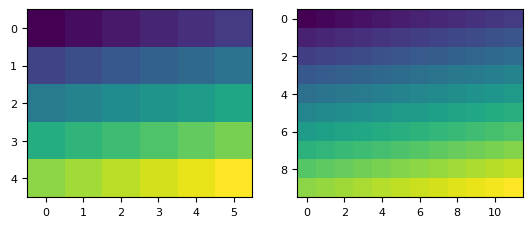

In [16]:
from matplotlib.pyplot import figure, show

fig = figure()
fr1 = fig.add_subplot(1,2,1)
fr2 = fig.add_subplot(1,2,2)
fr1.imshow(I, interpolation='none')
fr2.imshow(Iout, interpolation='none')
show()

### Template program for regridding
Now we are confident that our interpolation works and we can apply it to a FITS file.  
We start wit a 100x100 HI image of NGC6946. For a smoother image, we want to resample the image to get twice as much pixels in both $x$ and $y$ by using bilinear interpolation.

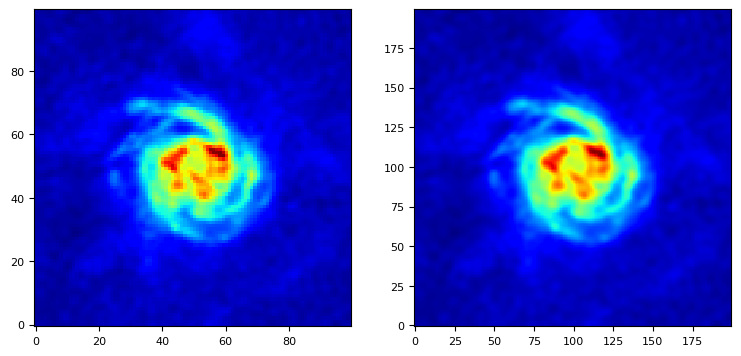

In [17]:
from astropy.io import fits

hdulist = fits.open('pictures/ngc6946.fits')
# hdulist.info()
datIN = hdulist[0].data
hdulist.close()

rows = 200; cols = 200
datOUT = np.zeros((rows,cols)) * np.nan
Y = np.linspace(0, datIN.shape[0]-1, rows)
X = np.linspace(0, datIN.shape[1]-1, cols)

for i,Yip in enumerate(Y):
    for j,Xip in enumerate(X):        
        datOUT[i,j] = bilinearIP(datIN, Xip, Yip)
                
fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

### Rotating an image using bilinear interpolation
<font color='red'>Important for image processing</font>

For regridding an rotation, the algorithm is to start sampling your (yet non existing) output image. 
Every pixel position in that image is rotated **clockwise** to get a position that corresponds to a position in the input image. Usually this will not be a grid point in this image so we have to interpolate to get a pixel value at that position. Then we store this pixel value in the output image at the grid position we started with.  
The result is that we nicely cover the entire output image and effectively we rotated the input **counter clockwise**. 

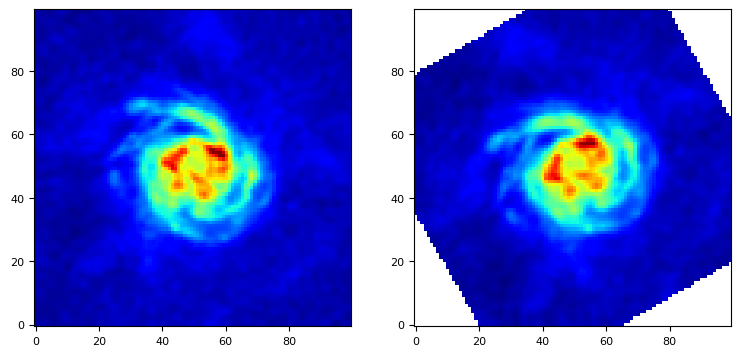

In [18]:
from astropy.io import fits

hdulist = fits.open('pictures/ngc6946.fits')
# hdulist.info()
datIN = hdulist[0].data
hdulist.close()

X0 = Y0 = 50
alpha = np.radians(30)

datOUT = np.zeros_like(datIN)*np.nan
for i in range(datOUT.shape[0]):
    for j in range(datOUT.shape[1]):
        # We need to rotate clockwise to find this position 
        # in the unrotated image!
        Xip =  np.cos(alpha)*(j-X0) + np.sin(alpha)*(i-Y0)  
        Yip = -np.sin(alpha)*(j-X0) + np.cos(alpha)*(i-Y0)
        Xip += X0 ; Yip += Y0
        datOUT[i,j] = bilinearIP(datIN, Xip, Yip)
                
fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

### Speeding up the rotation

We developed code to apply bilinear interpolation to properly rotate an image. Now it's time to explore some options to speedup the execution. First we identify that the positions for the rotation can be calculated in a vectorized way using NumPy arrays:

In [19]:
xg = np.arange(0, datIN.shape[1])
yg = np.arange(0, datIN.shape[0])

M = np.meshgrid(xg, yg)
X, Y = M
X0 = Y0 = 50
alpha = np.radians(30)

Xr =  np.cos(alpha)*(X-X0) + np.sin(alpha)*(Y-Y0)  # "clockwise"
Yr = -np.sin(alpha)*(X-X0) + np.cos(alpha)*(Y-Y0)
Xr += X0
Yr += Y0

Xr = np.array(Xr).reshape(datIN.shape)
Yr = np.array(Yr).reshape(datIN.shape)

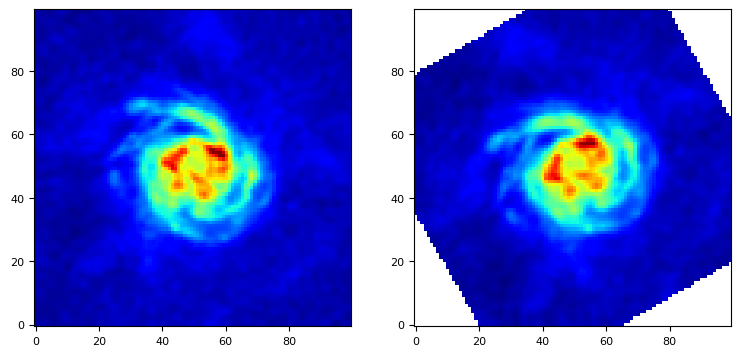

In [20]:
datOUT = np.zeros_like(datIN)*np.nan
for i in range(datOUT.shape[0]):
    for j in range(datOUT.shape[1]):        
        Xip = Xr[i,j]
        Yip = Yr[i,j]
        datOUT[i,j] = bilinearIP(datIN, Xip, Yip)
        
        
fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

### Speeding up with ``numpy.ndindex`` by avoiding an inner loop

Nested loops are an important cause of long execution times. We can avoid the inner loop in the previous example by generating our indices with function ``numpy.ndindex()``. This
function has one argument and that is the shape of the data structure for which we want to find the indices. If we know the dimension beforehand, we can unpack the indices from the generated tuples which contain the indices.

We applied this function in the example below:

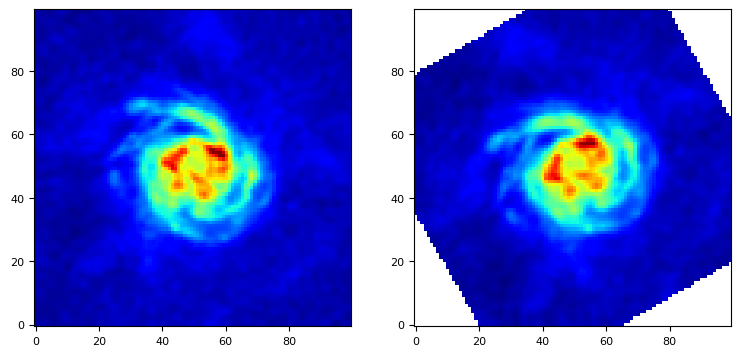

In [21]:
datOUT = np.zeros_like(datIN)*np.nan
for i,j in np.ndindex(datOUT.shape):
    Xip = Xr[i,j]
    Yip = Yr[i,j]
    datOUT[i,j] = bilinearIP(datIN, Xip, Yip)
        
        
fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

### Avoiding cutoffs
To get the rotated image without cutoffs, one should start with an output image which is bigger so that we don't miss pixels from the input image.

We scale the output image with some factor.
Then we shift positions so that they are relative to a new rotation center (e.g. the center of the image). The we apply rotation to the positions, but we have to shift them to become relative to position (0,0) in the input. However this shift is different compared to
the previous because we are shifting in the original image now.

First repeat the definition of our function ``bilinearIP()`` and then we write some lines to calculate what the new axis lengths will be so that we can calculate a grid that contains the entire image. We do this by rotating the corners of the input image and calculates the new 
axis length in $x$ and $y$.

#### The bilinear interpolation function ``bilinearIP``

We use our previously defined function ``bilinearIP()``from this notebook.

#### Read the input data

In [22]:
hdulist = fits.open('pictures/ngc6946.fits')
# hdulist.info()
datIN = hdulist[0].data
hdulist.close()

#### Calculating a new box by rotating the limits of the input data

In [23]:
alpha = np.radians(30)        # Rotate image alpha radians counter clockwise
leny = datIN.shape[0]
lenx = datIN.shape[1]

# Put rotation center in the middle of the image
X0in = lenx//2
Y0in = leny//2
# Rotate the coordinates (0,leny) and (lenx,0)
lenx1 = 0*np.cos(alpha) - leny*np.sin(alpha)
leny1 = 0*np.sin(alpha) + leny*np.cos(alpha)
lenx2 = lenx * np.cos(alpha) - 0*np.sin(alpha)
leny2 = lenx * np.sin(alpha) + 0*np.cos(alpha)
# Add the absolute value of negative coordinates
newlenx = int(abs(lenx1) + abs(lenx2))
newleny = int(abs(leny1) + abs(leny2))

#### Use the new limits to sample the output image

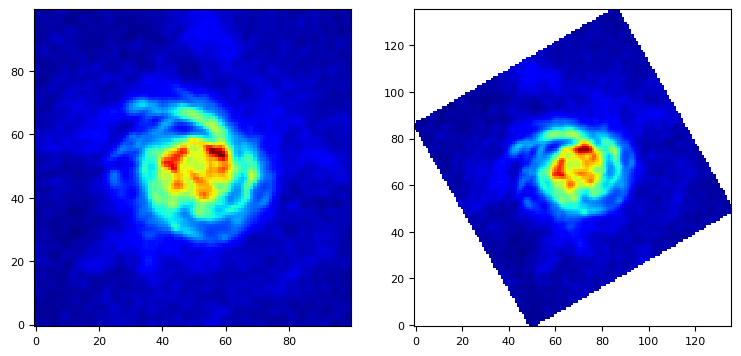

In [24]:
leny = datIN.shape[0]
lenx = datIN.shape[1]

xg = np.arange(0, newlenx)
yg = np.arange(0, newleny)

M = np.meshgrid(xg, yg)
X, Y = M
# Rotation center in output image
X0out = newlenx//2   #int(X0in*scaleX)
Y0out = newleny//2   #int(Y0in*scaleY)

# Rotate all positions (tuples) in our meshgrid
Xr =  (X-X0out)*np.cos(alpha) + (Y-Y0out)*np.sin(alpha)  # "clockwise"
Yr = -(X-X0out)*np.sin(alpha) + (Y-Y0out)*np.cos(alpha)
Xr += X0in
Yr += Y0in

newshape = (newleny, newlenx)
Xr = np.array(Xr).reshape(newshape)
Yr = np.array(Yr).reshape(newshape)

# Create a new data structure with the new shape and fill with NaN's
datOUT = np.full(newshape, np.nan)

# Loop over all coordinate pairs and find interpolated intensity
for i,j in np.ndindex(datOUT.shape):
    Xip = Xr[i,j]
    Yip = Yr[i,j]
    datOUT[i,j] = bilinearIP(datIN, Xip, Yip)
             
fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

## Rotation routines from Python modules

Several modules provide functions which rotate images. One cannot use ``interp2d`` because that function interpolates in rectangular non rotated grids. 

Module ``scipy.ndimage`` provides a routine which does the interpolation with splines.
See the example in the next cell.

This, and some other function for rotating images, are defined for images like JPG's or PNG's. There the data is ordered from top to bottom. So we should flip the $y$ axis in our FITS data first.

Then there is no need to set ``origin='lower'`` in Matplotlib's ``imshow()`` to display the image correctly.

### Rotate with the ``ndimage`` module from SciPy

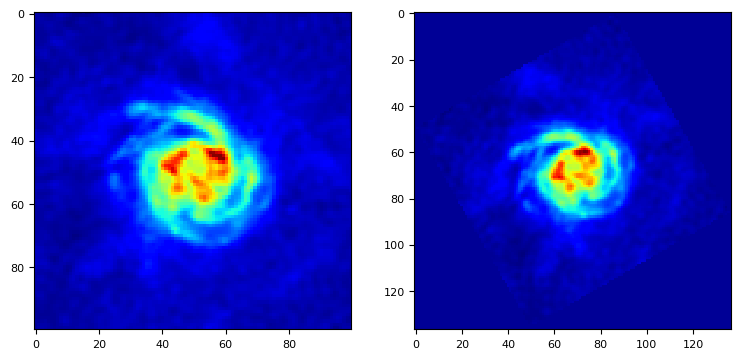

In [25]:
from scipy.ndimage import rotate

alpha = 30   # Now it is in degrees
datINflipped = datIN[::-1,:]
datOUT = rotate(datINflipped, alpha, order=1)

fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datINflipped, interpolation='none', cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', cmap='jet')

show()

###  Rotation with module Pillow

* The module is imported with ``PIL``
* It has much functionality to process images
* We read image objects from PNG, JPG etc. or from a NumPy 2D array
* We create an image object from an array with the ``PIL.Image.fromarray()`` function
* An PIL image has a method ``rotate``
* This method rotates about the image center over an angle in degrees
* We create a 2D array from this rotated image with ``numpy.asarray()``
* By default, no interpolation will be applied (nearest pixel only)
* With parameter ``resample`` we set an interpolatie mode
* Use parameter ``expand`` to prevent cutoffs at the edges
* Information about the Image module can be found at https://pillow.readthedocs.io/en/3.1.x/reference/Image.html

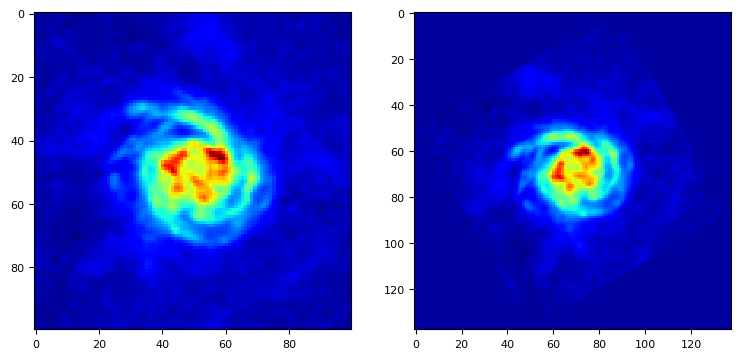

In [26]:
from PIL import Image
datINflipped = datIN[::-1,:]
im = Image.fromarray(datINflipped)
rotated = im.rotate(30, resample=Image.BILINEAR, expand=True)
datOUT = np.asarray(rotated)

fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datINflipped, interpolation='none', cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', cmap='jet')

show()

### Rotate an image with OpenCV

OpenCV is a powerful module for image processing. Currently there is not a version available that is compatible with our Anaconda distribution. As soon there is an installable version, we will update this notebook.